In [54]:
%load_ext autoreload
%autoreload 2
import os
import sys
import json
import numpy as np
import pandas as pd
import itertools
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

MPL_CUSTOM = {
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi': 120,
    'figure.figsize': (4, 3.5),
    'figure.facecolor': 'white',
    'xtick.top': True,
    'xtick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.right': True,
    'ytick.direction': 'in',
    'ytick.minor.visible': True,
}

for k, v in MPL_CUSTOM.items():
    mpl.rcParams[k] = v

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
try:
    import ROOT
except ImportError as e:
    env_lib = Path(os.environ['CONDA_PREFIX']) / 'lib'
    sys.path.append(list(env_lib.glob('python*/site-packages'))[-1])
    import ROOT


In [56]:
def TH1D_to_df(hist,  xname='x', yname='y', keep_zeros=True):
    df = dict()
    columns = [xname, yname, f'{yname}_err']
    getters = [hist.GetXaxis().GetBinCenter, hist.GetBinContent,
                hist.GetBinError]
    for col, get in zip(columns, getters):
        df[col] = [get(b) for b in range(1, hist.GetNbinsX() + 1)]

    df = pd.DataFrame(df)
    condition = (df[yname] != 0.0)
    df[f'{yname}_ferr'] = np.where(
        condition, np.abs(df[f'{yname}_err']/df[yname]), 0.0)

    return df if keep_zeros else df.query(f'{yname} != 0.0').reset_index(drop=True)


def TH2D_to_df(histo, xname='x', yname='y', zname='z', keep_zeros=True):
    x = np.array([histo.GetXaxis().GetBinCenter(b)
                    for b in range(1, histo.GetNbinsX() + 1)])
    y = np.array([histo.GetYaxis().GetBinCenter(b)
                    for b in range(1, histo.GetNbinsY() + 1)])

    content = np.array(histo)
    content = content.reshape(len(x) + 2, len(y) + 2, order='F')
    content = content[1:-1, 1:-1]

    error = np.array([histo.GetBinError(b)
                        for b in range((len(x) + 2) * (len(y) + 2))])
    error = error.reshape(len(x) + 2, len(y) + 2, order='F')
    error = error[1:-1, 1:-1]

    xx, yy = np.meshgrid(x, y, indexing='ij')
    df = pd.DataFrame({
        xname: xx.flatten(),
        yname: yy.flatten(),
        zname: content.flatten(),
        f'{zname}_err': error.flatten(),
    })
    mask = (df[zname] != 0.0)
    df[f'{zname}_ferr'] = np.where(
        mask,
        np.abs(df[f'{zname}_err'] / df[zname]),
        0.0
    )
    return df if keep_zeros else df.query(f'{zname} != 0.0').reset_index(drop=True)


In [57]:
current_dir = Path.cwd()
main_dir = current_dir.parent

In [58]:
module_pos = pd.read_csv(main_dir / 'database/module_positions.dat', sep=r'\s+', skiprows=1)

In [59]:
# all.root  backward.root  backwarda.root  backwardb.root  bottom.root  forward.root
shadow_settings = ['forward', 'backward', 'backwarda', 'backwardb', 'bottom', 'all']

hitpattern_vetoed = {k : {} for k in shadow_settings}
hitpattern_noveto = {k : {} for k in shadow_settings}

for shadow in shadow_settings:
    file = ROOT.TFile(str(main_dir / 'results/hit_pattern/shadow_no_veto' / f'{shadow}.root'), 'read')
    for key in file.GetListOfKeys():
        hist_name = key.GetName()
        hist = file.Get(hist_name).Clone(hist_name + '_' + shadow)
        hitpattern_noveto[shadow][hist_name] = TH2D_to_df(hist)
    
    file = ROOT.TFile(str(main_dir / 'results/hit_pattern/shadow_vetoed' / f'{shadow}.root'), 'read')
    for key in file.GetListOfKeys():
        hist_name = key.GetName()
        hist = file.Get(hist_name).Clone(hist_name + '_' + shadow)
        hitpattern_vetoed[shadow][hist_name] = TH2D_to_df(h ist)


In [60]:
shadow_bar_coordinates = {
    1 : [(280,181), (280,274), (182,274), (182,181)],
    2 : [(-184,181), (-184,274), (-278,274), (-277,181)],
    3 : [(-181,-276), (-181,-184), (-280,-184), (-280,-277)],
    4 : [(277,-279), (276,-181), (184,-181), (185,-280)],
    5 : [(80,-25), (80,-67), (-28,-67), (-28,-25)],
}

In [61]:
# 'forward', 'backward', 'backwarda', 'backwardb', 'bottom', 'all'
shadow_bar_placed = {
    'forward' : [2,3],
    'bottom' : [3,4],
    'backward' : [4],
    'backwarda' : [4],
    'backwardb' : [4],
    'all' : [2,3,4],
}

In [62]:
cmap = mpl.cm.get_cmap('rainbow')
cmap.set_bad('w', 1.0)

/tmp/ipykernel_1446085/1851709959.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('rainbow')


In [63]:
def projection(df, x_range, y_range, bins, axis='x'):
    cut_axis = 'x' if axis == 'y' else 'y'
    cut_range = x_range if axis == 'y' else y_range
    hist_range = x_range if axis == 'x' else y_range
    
    df = df.query(f'{cut_axis} > {cut_range[0]} and {cut_axis} < {cut_range[1]}')
    
    hist, edges = np.histogram(
        df[axis], bins, range=hist_range, weights=df['z'])
    hist_err, _ = np.histogram(
        df[axis], bins, range=hist_range, weights=df['z_err']**2)
    hist_err = np.sqrt(hist_err)
    x = (edges[1:] + edges[:-1]) / 2
    return pd.DataFrame({
        'x': x,
        'y': hist,
        'y_err': hist_err,
        'y_ferr': np.divide(hist_err, hist, out=np.zeros_like(hist), where=hist!=0)
    })


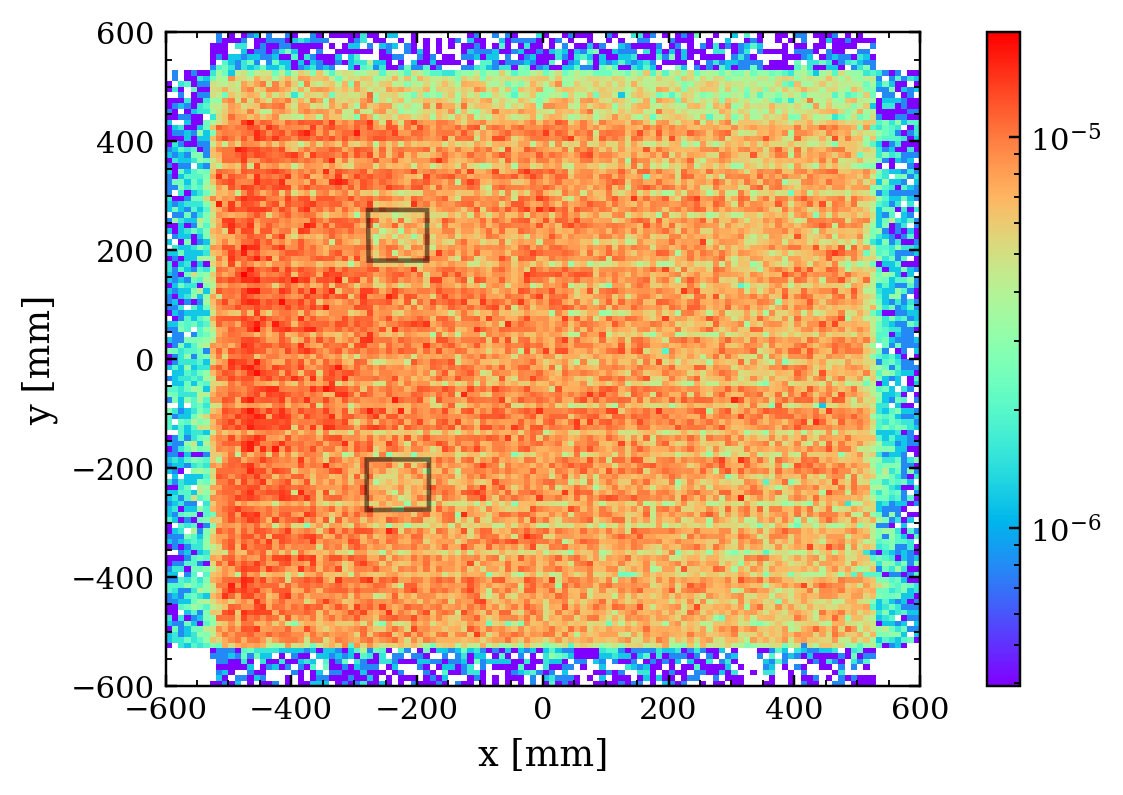

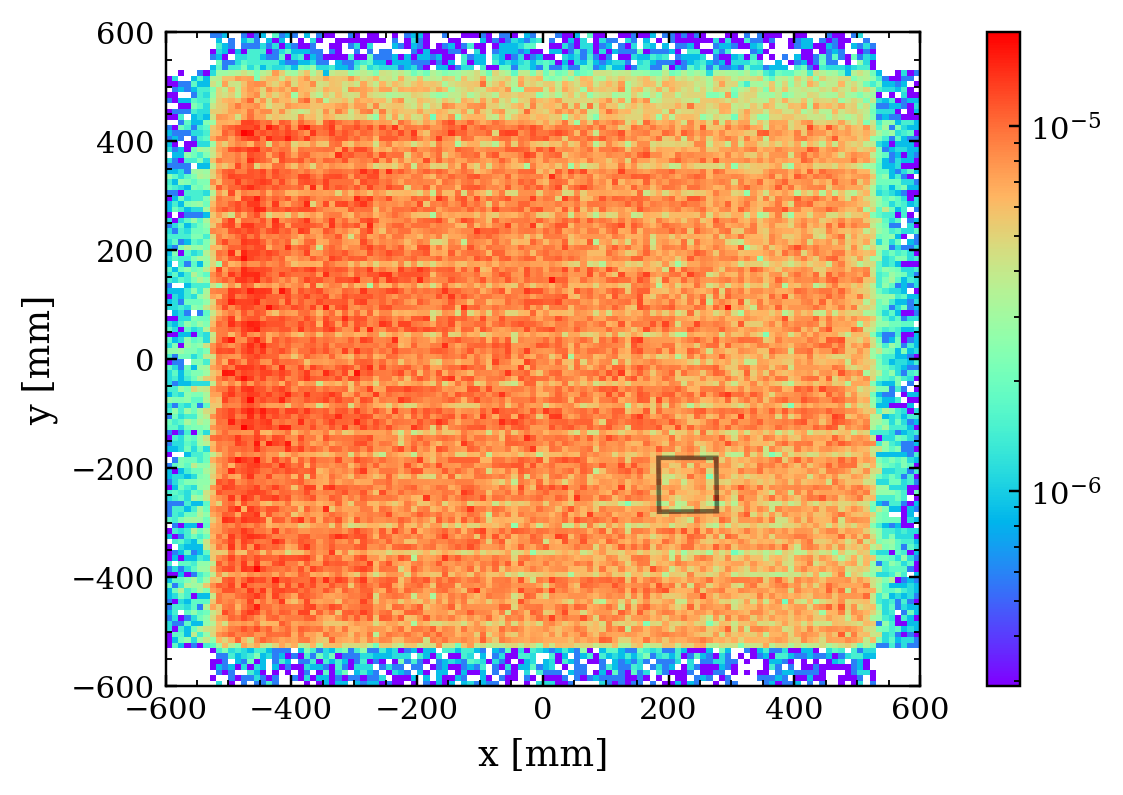

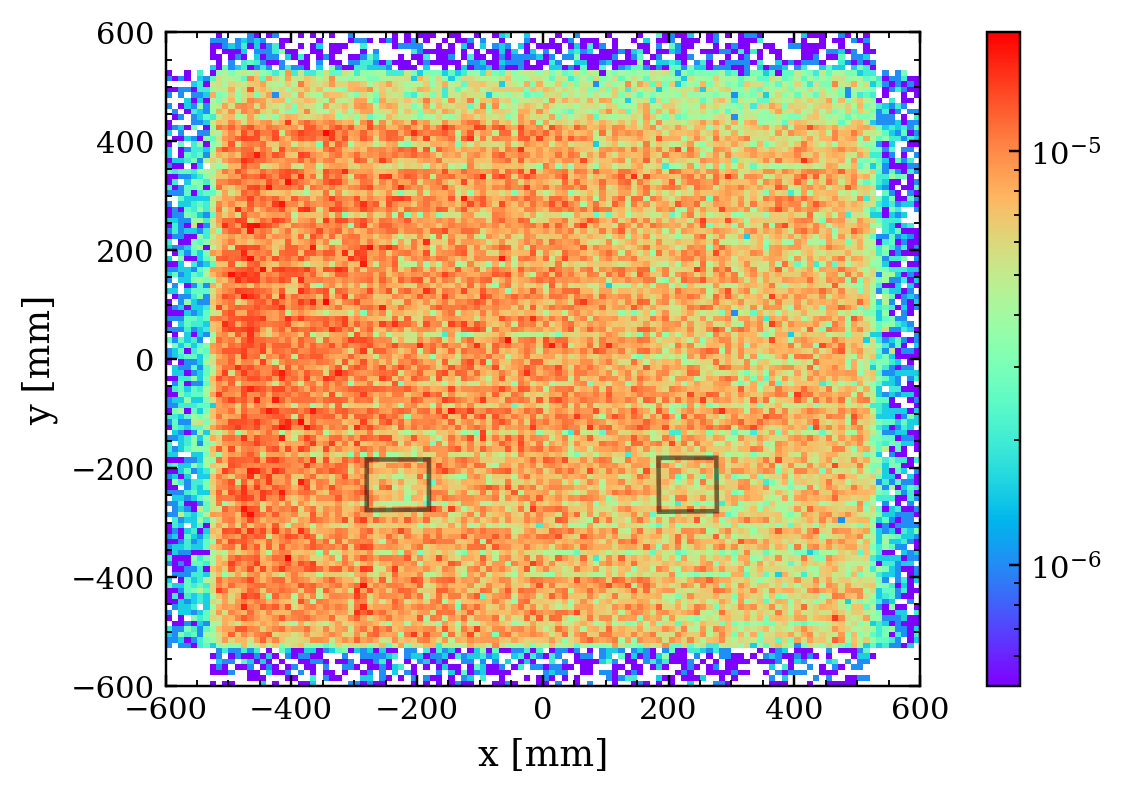

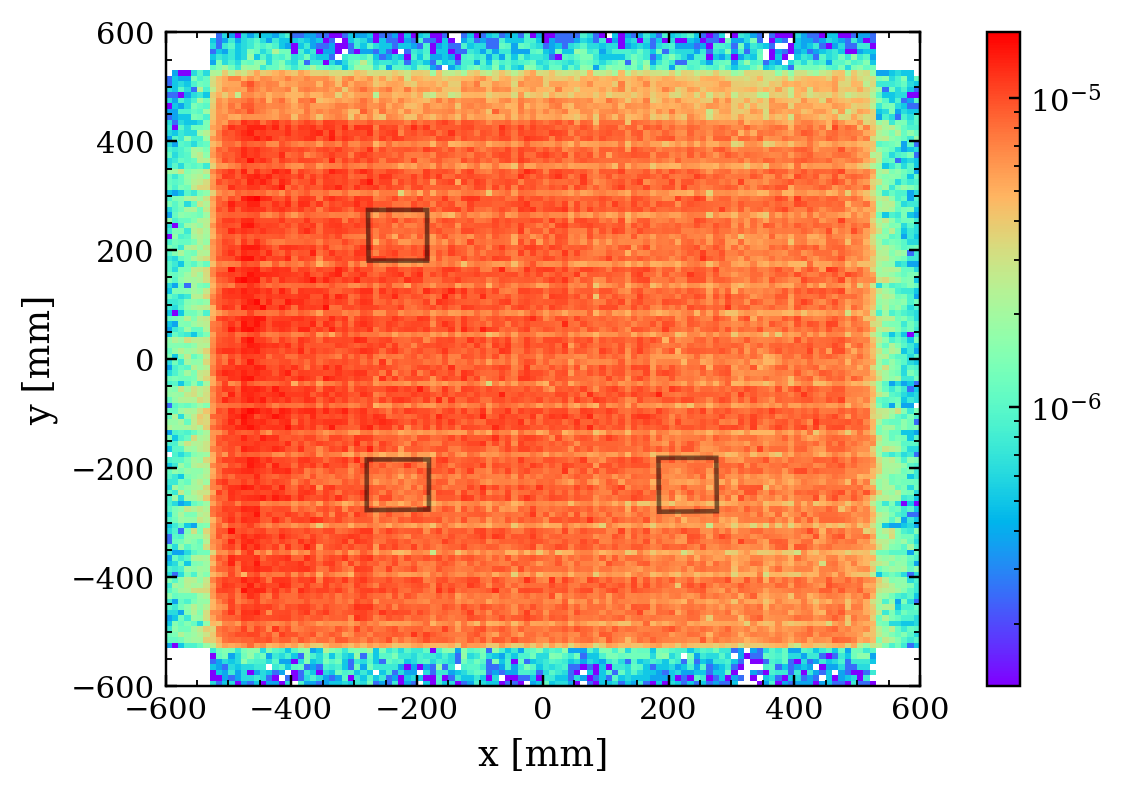

In [65]:
projected_shadow = {
   shadow : {} for shadow in shadow_settings
}

# for shadow in ['all']:
for shadow in ['forward', 'backward', 'bottom', 'all']:
    df_vetoed = hitpattern_vetoed[shadow][f'hHitPattern'].copy()

    # df_vetoed.query('z > 2e-6', inplace=True)

    fig, ax = plt.subplots(1,1, figsize=(5,3.5), dpi=220, constrained_layout=True)
    h1 = ax.hist2d(
        df_vetoed['x'], 
        df_vetoed['y'], 
        weights=df_vetoed['z'],
        bins=(200, 200), 
        range=((-1000, 1000), (-1000, 1000)),
        cmap=cmap, 
        norm=mpl.colors.LogNorm()
    )
    cbar1 = fig.colorbar(h1[3], ax=ax)

    ax.set_xlabel('x [mm]', fontsize=12)
    ax.set_ylabel('y [mm]', fontsize=12)

    ax.set_xlim(-600,600)
    ax.set_ylim(-600,600)

    # ax.axhline(-100, color='b', linestyle='--', linewidth=1)
    # ax.axhline(100, color='b', linestyle='--', linewidth=1)

    for shadow_id in shadow_bar_placed[shadow]:
        coor = shadow_bar_coordinates[shadow_id]
        ax.add_patch(
            mpl.patches.Polygon(
                coor, 
                linewidth=1.5, 
                alpha=0.5,
                fill=False,
                edgecolor='k',
            )
        )

    # for shadow_id in [2,4]:
    #     coor = shadow_bar_coordinates[shadow_id]
    #     ax.axhline(coor[0][1], color='k', linestyle='--', linewidth=0.5)
    #     ax.axhline(coor[1][1], color='k', linestyle='--', linewidth=0.5)

    # for shadow_id in shadow_bar_placed[shadow]:
    #     coor = shadow_bar_coordinates[shadow_id]
    #     projected_shadow[shadow][shadow_id] = projection(
    #         df_vetoed, 
    #         x_range=[-1000,1000], 
    #         y_range=[coor[0][1],coor[1][1]], 
    #         bins=50, 
    #         axis='x'
    #     )

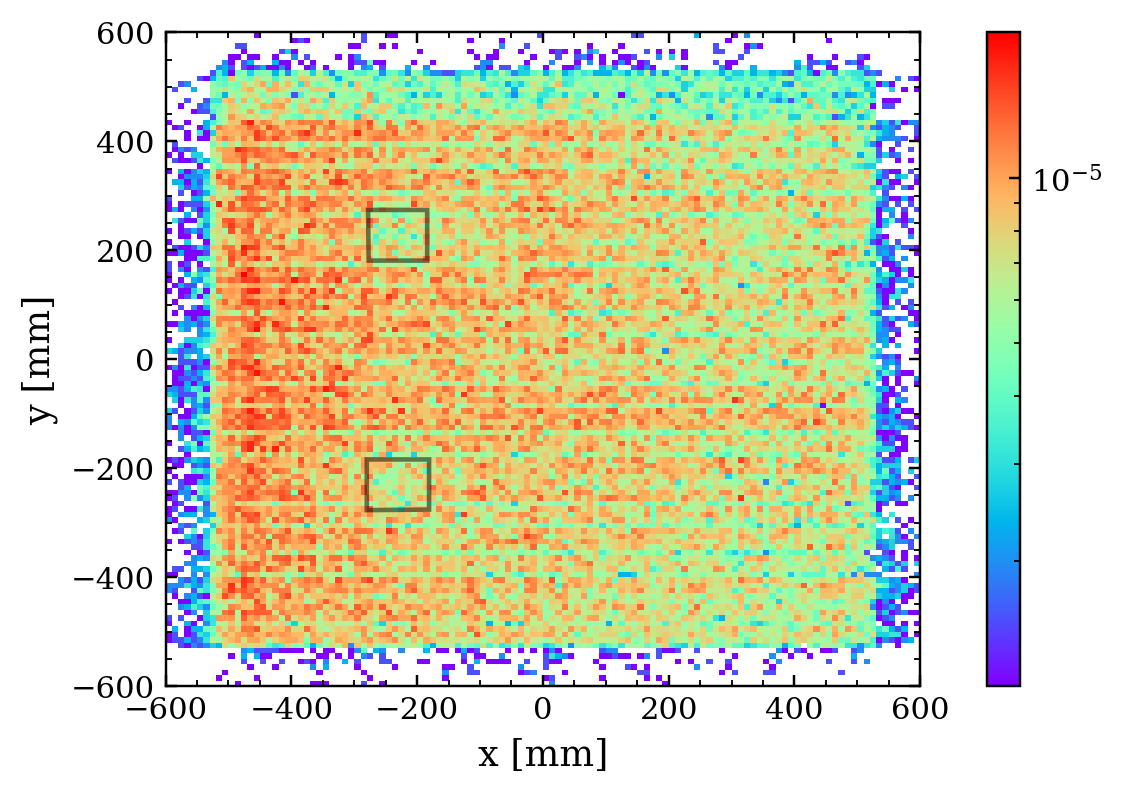

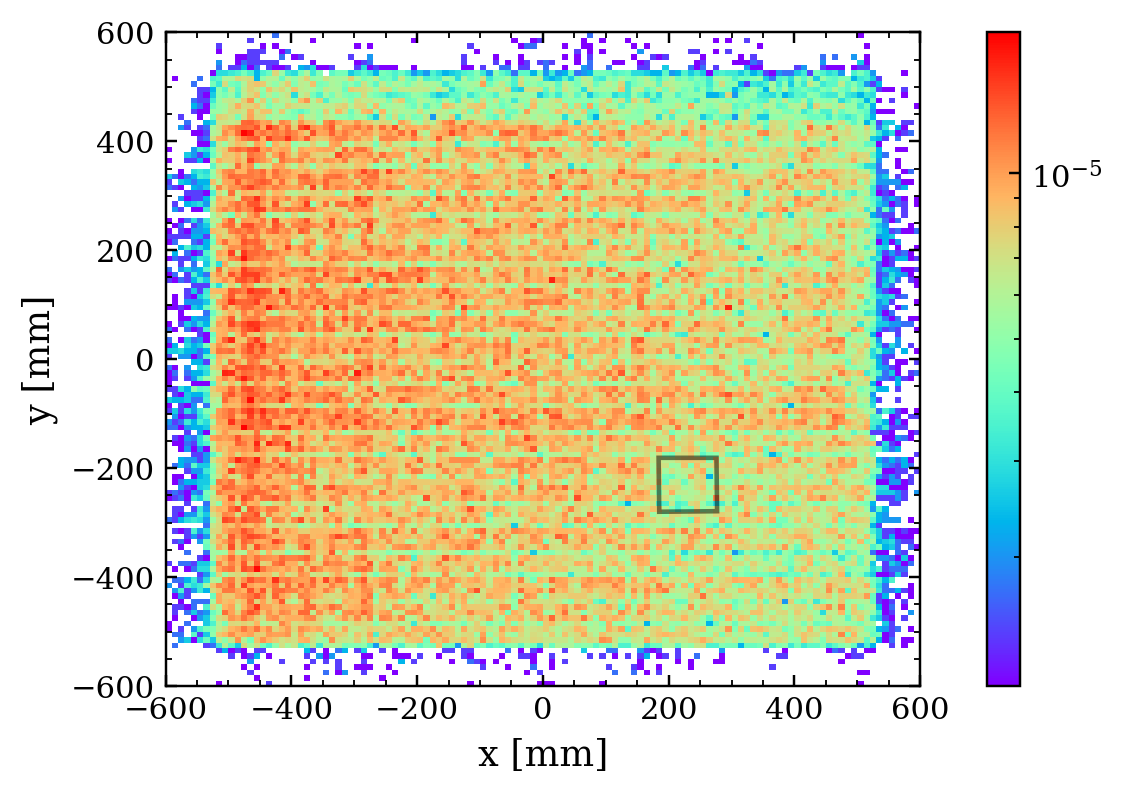

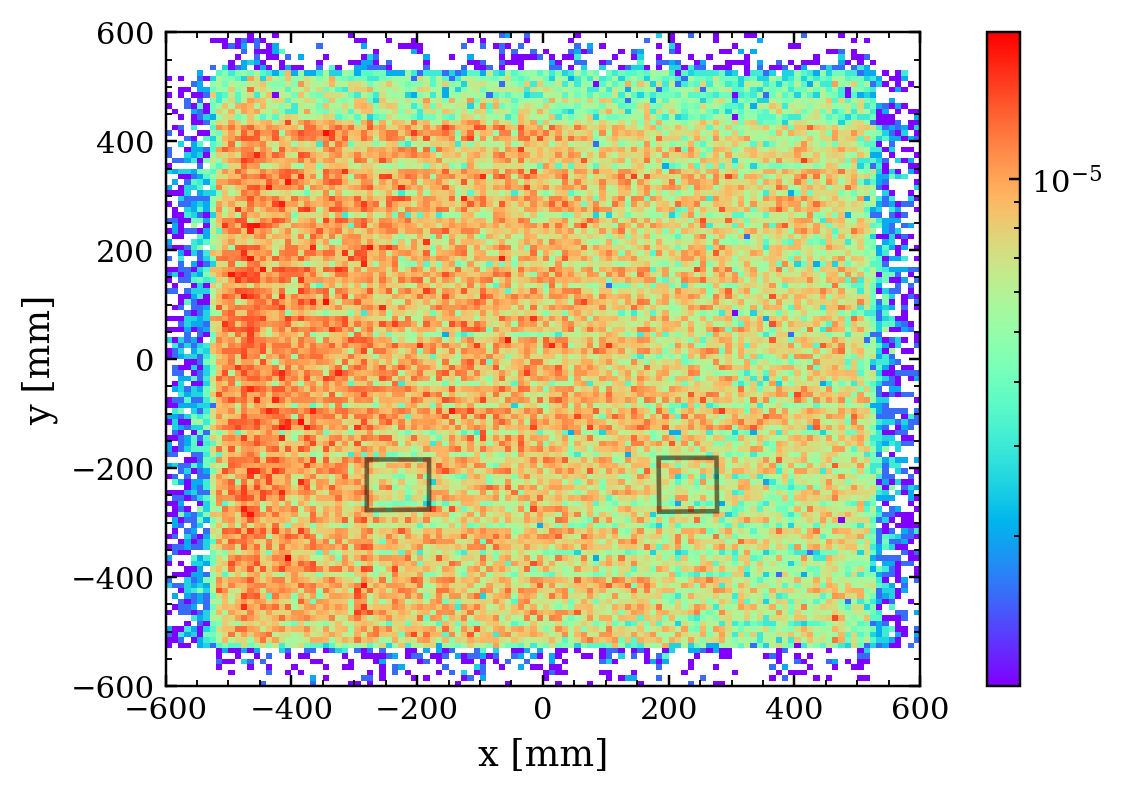

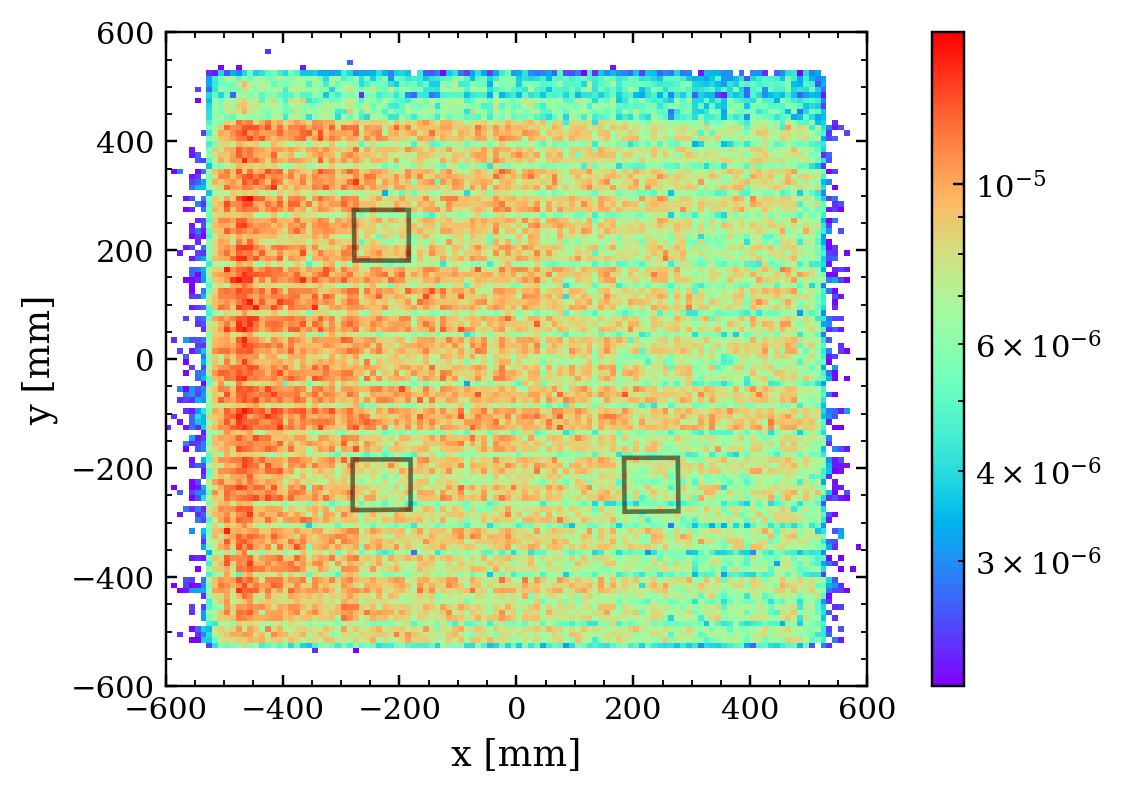

In [70]:
projected_shadow = {
   shadow : {} for shadow in shadow_settings
}

# for shadow in ['all']:

thres = {
    'forward' : 1e-6,
    'backward' : 1e-6,
    'bottom' : 1e-6,
    'all' : 2e-6,
}

for shadow in ['forward', 'backward', 'bottom', 'all']:
    df_vetoed = hitpattern_vetoed[shadow][f'hHitPattern'].copy()

    df_vetoed.query(f'z > {thres[shadow]}', inplace=True)

    fig, ax = plt.subplots(1,1, figsize=(5,3.5), dpi=220, constrained_layout=True)
    h1 = ax.hist2d(
        df_vetoed['x'], 
        df_vetoed['y'], 
        weights=df_vetoed['z'],
        bins=(200, 200), 
        range=((-1000, 1000), (-1000, 1000)),
        cmap=cmap, 
        norm=mpl.colors.LogNorm()
    )
    cbar1 = fig.colorbar(h1[3], ax=ax)

    ax.set_xlabel('x [mm]', fontsize=12)
    ax.set_ylabel('y [mm]', fontsize=12)

    ax.set_xlim(-600,600)
    ax.set_ylim(-600,600)

    # ax.axhline(-100, color='b', linestyle='--', linewidth=1)
    # ax.axhline(100, color='b', linestyle='--', linewidth=1)

    for shadow_id in shadow_bar_placed[shadow]:
        coor = shadow_bar_coordinates[shadow_id]
        ax.add_patch(
            mpl.patches.Polygon(
                coor, 
                linewidth=1.5, 
                alpha=0.5,
                fill=False,
                edgecolor='k',
            )
        )
